#EDA

DATASET OVERVIEW
Shape: (140, 8)

Columns:
['NPA', 'heat_index', 'impervious_pct', 'tree_canopy_pct', 'housing_density', 'job_density', 'commercial_construction', 'tree_to_impervious']

Missing Values:
NPA                        0
heat_index                 0
impervious_pct             0
tree_canopy_pct            0
housing_density            0
job_density                0
commercial_construction    0
tree_to_impervious         0
dtype: int64

Data Types:
NPA                          int64
heat_index                 float64
impervious_pct             float64
tree_canopy_pct            float64
housing_density            float64
job_density                float64
commercial_construction    float64
tree_to_impervious         float64
dtype: object

DESCRIPTIVE STATISTICS
       impervious_pct  tree_canopy_pct  housing_density  job_density  \
count          140.00           140.00           140.00       140.00   
mean            24.43            34.23          1283.33      2485.26   
std   

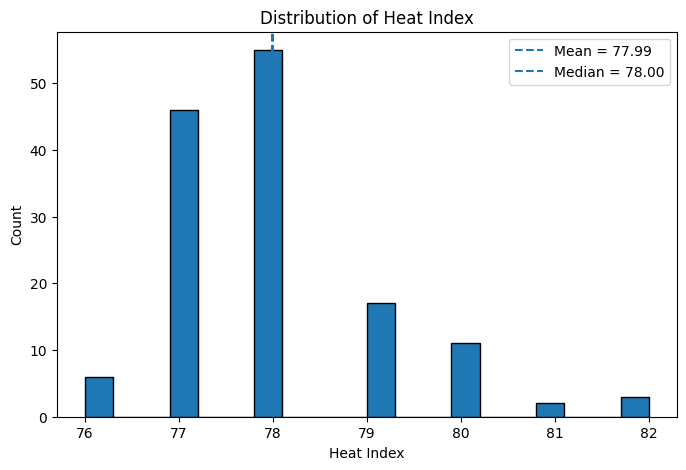

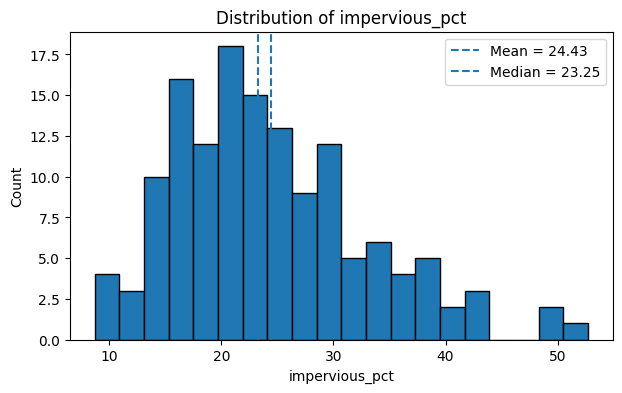

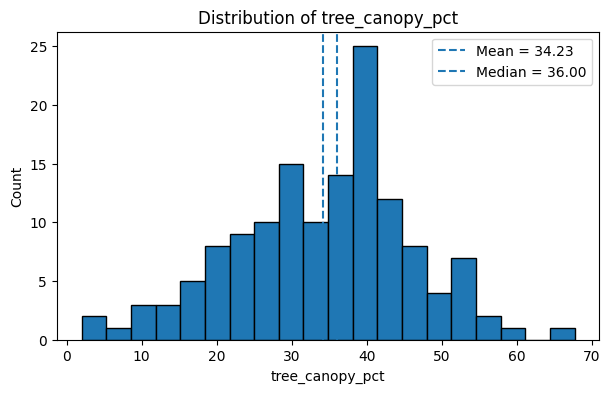

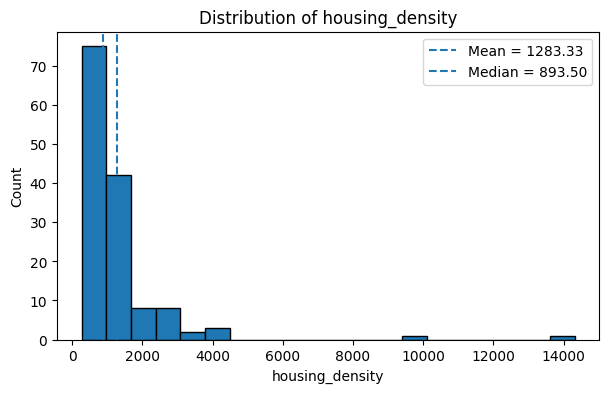

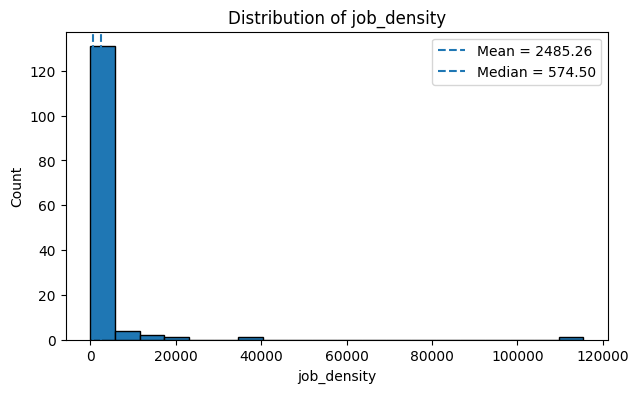

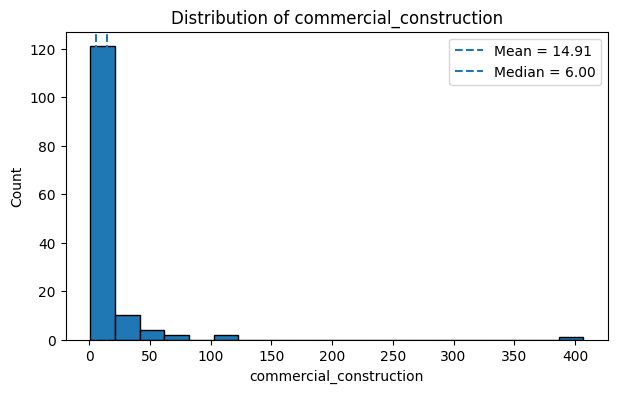

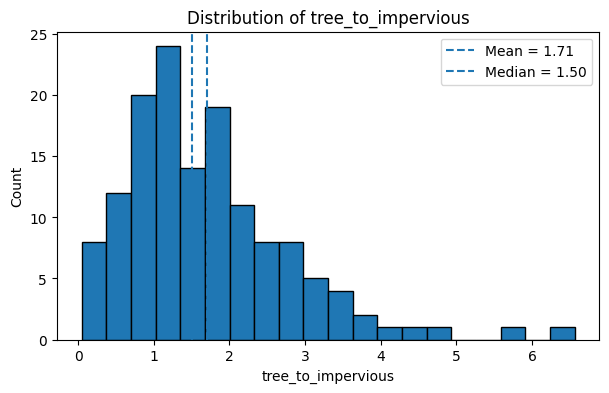

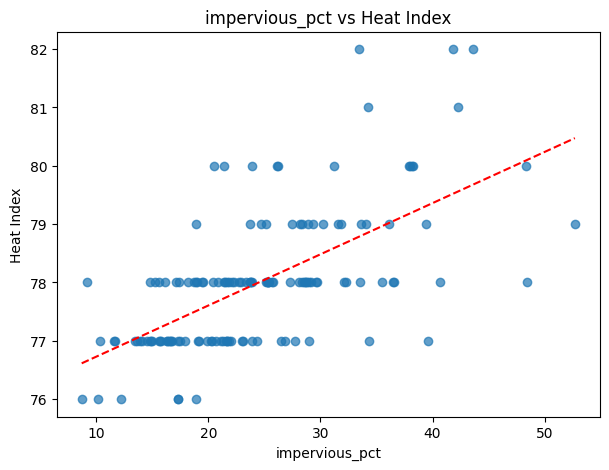

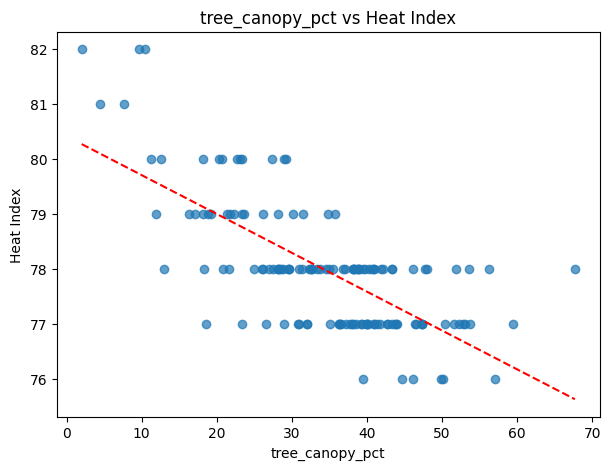

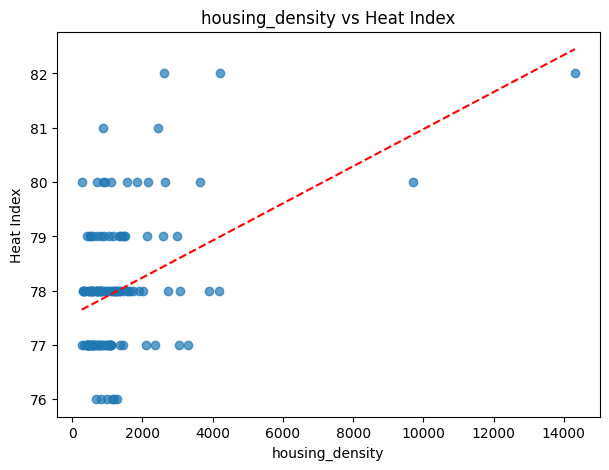

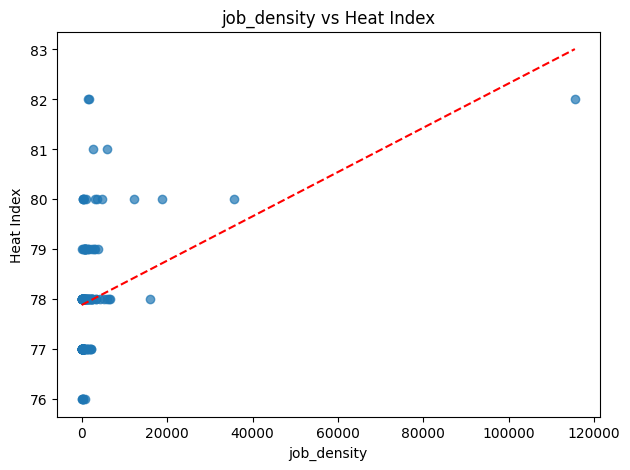

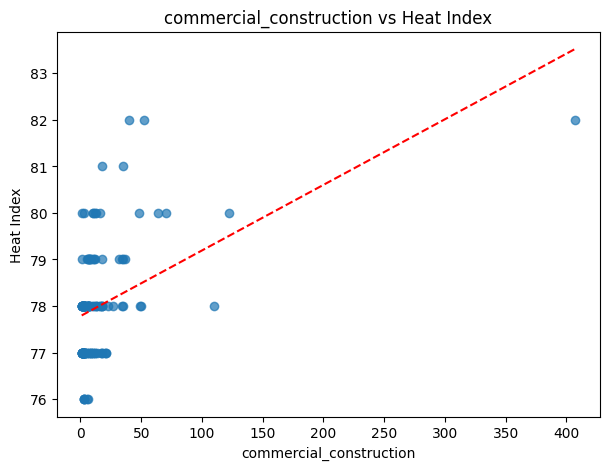

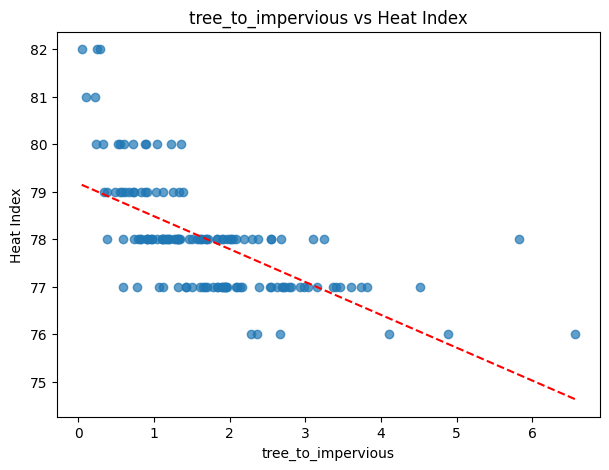

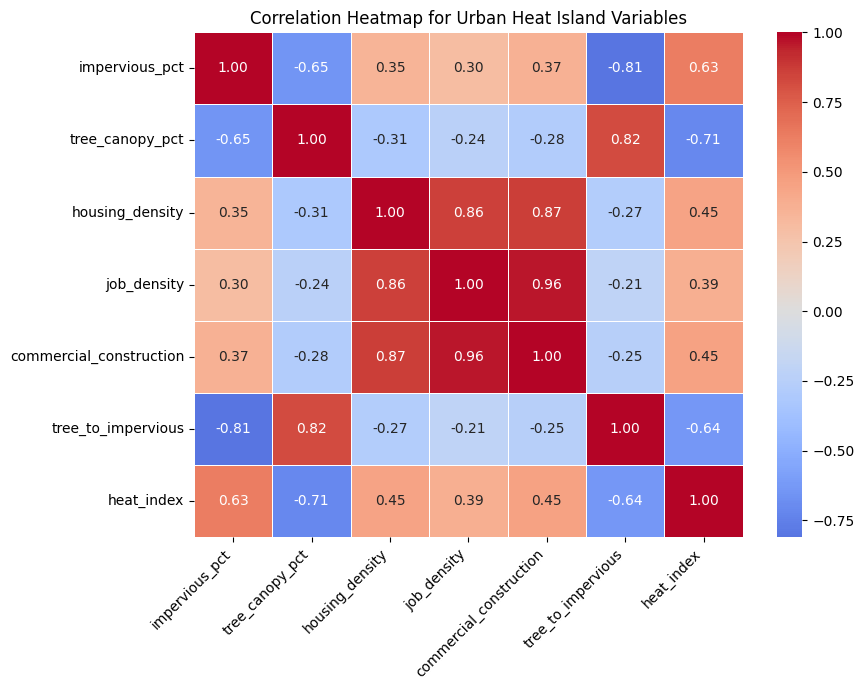

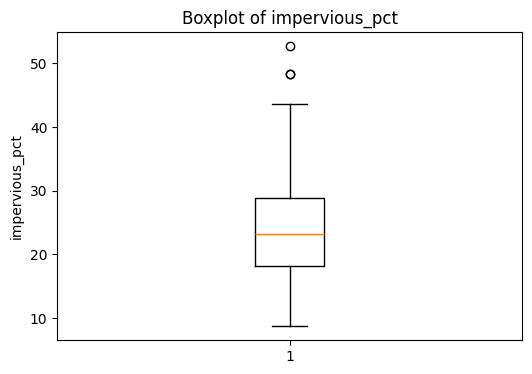

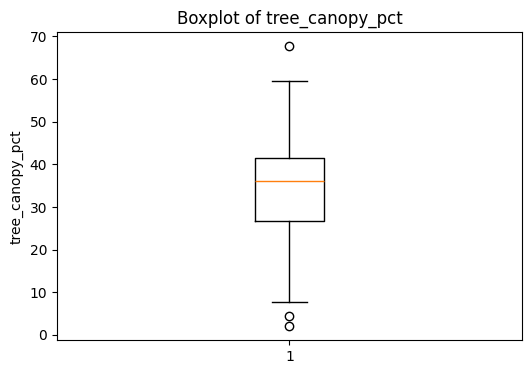

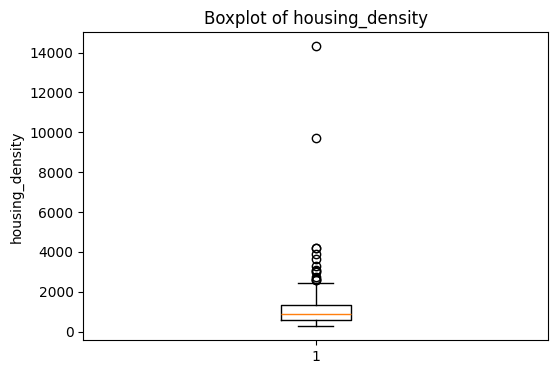

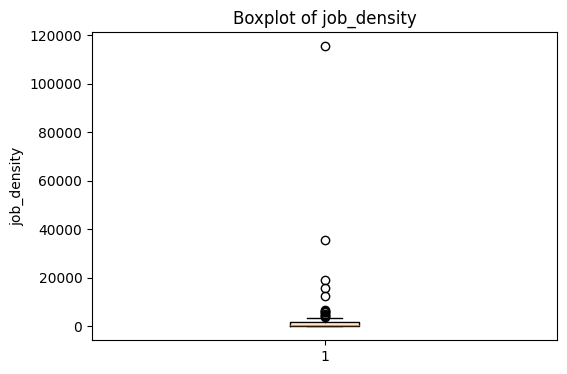

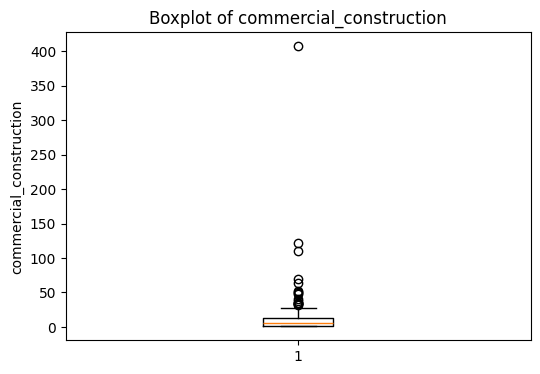

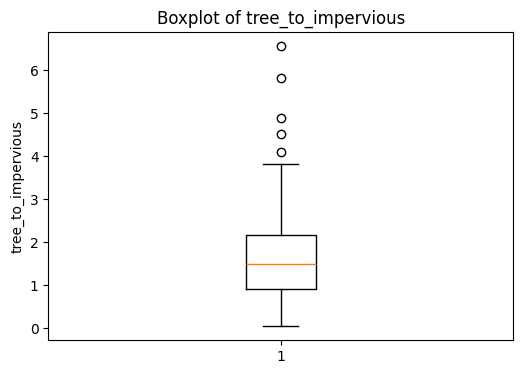


CLASSIFICATION TARGET
Median Heat Index: 78.0
heat_risk_label
Low Risk     107
High Risk     33
Name: count, dtype: int64
heat_risk_label
Low Risk     0.764
High Risk    0.236
Name: proportion, dtype: float64


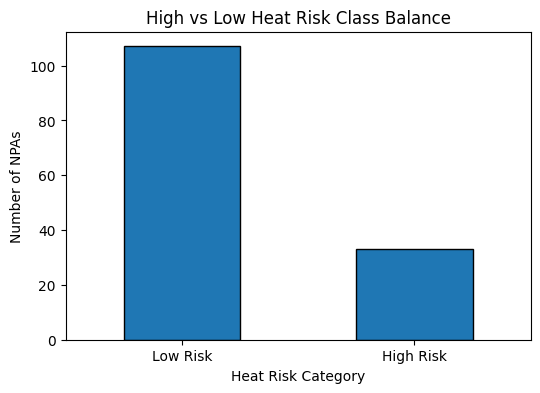

<Figure size 700x500 with 0 Axes>

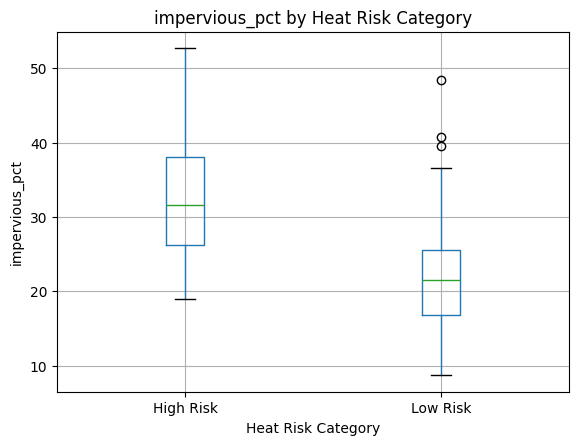

<Figure size 700x500 with 0 Axes>

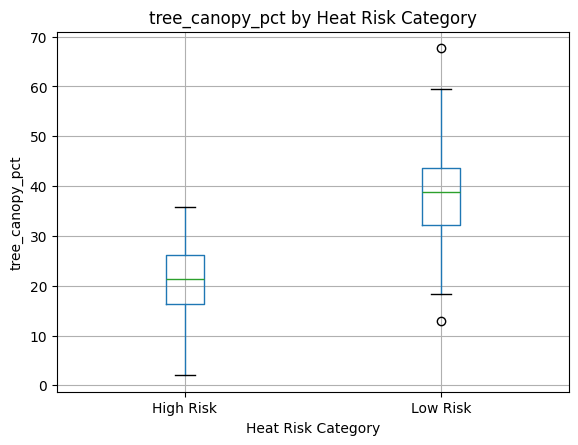

<Figure size 700x500 with 0 Axes>

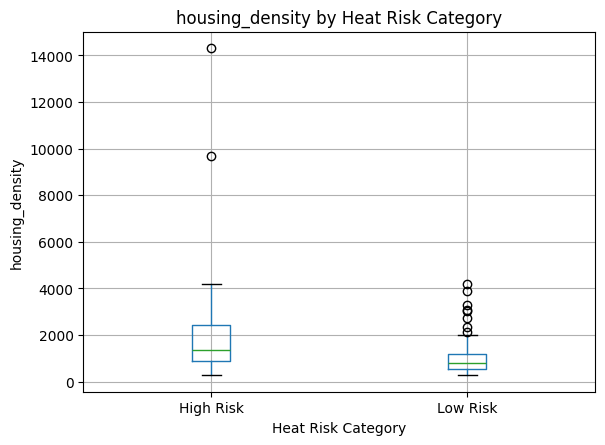

<Figure size 700x500 with 0 Axes>

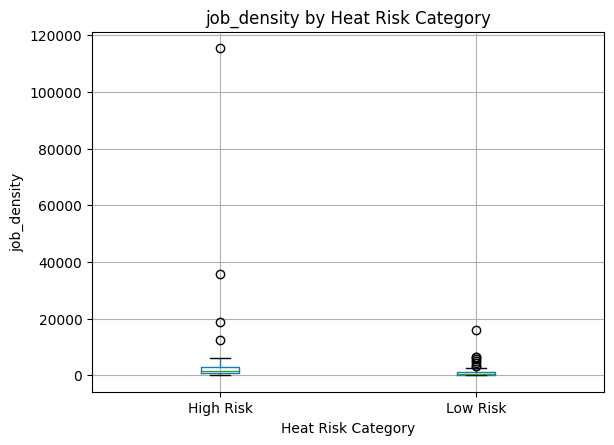

<Figure size 700x500 with 0 Axes>

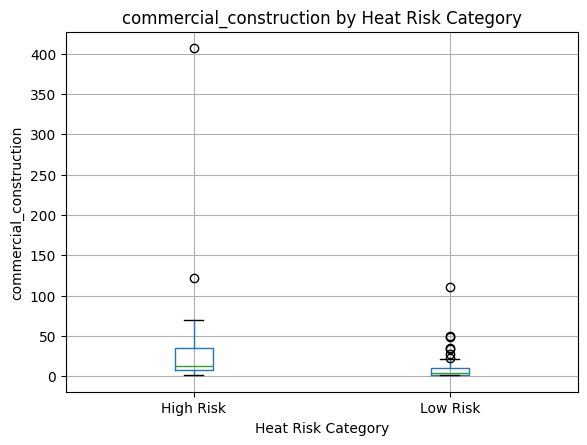

<Figure size 700x500 with 0 Axes>

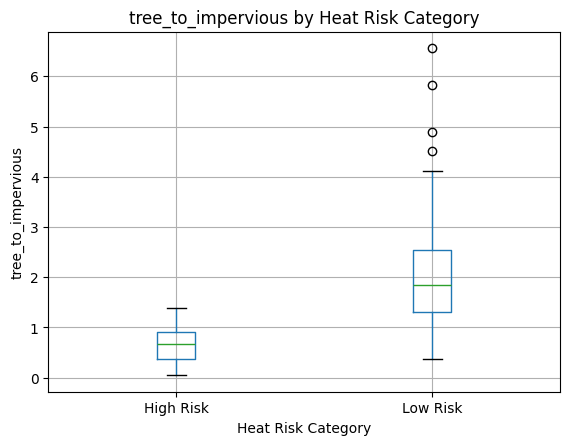

In [ ]:
# ============================================================
# EDA — EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure this matches your actual df columns
FEATURES = [
    "impervious_pct",
    "tree_canopy_pct",
    "housing_density",
    "job_density",
    "commercial_construction",
    "tree_to_impervious"
]

# ============================================================
# 1. DATASET OVERVIEW
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# ============================================================
# 2. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(df[FEATURES + ["heat_index"]].describe().round(2))

# ============================================================
# 3. HEAT INDEX DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["heat_index"], bins=20, edgecolor="black")
plt.axvline(df["heat_index"].mean(), linestyle="--", label=f"Mean = {df['heat_index'].mean():.2f}")
plt.axvline(df["heat_index"].median(), linestyle="--", label=f"Median = {df['heat_index'].median():.2f}")
plt.xlabel("Heat Index")
plt.ylabel("Count")
plt.title("Distribution of Heat Index")
plt.legend()
plt.show()

# ============================================================
# 4. FEATURE HISTOGRAMS
# ============================================================

for feature in FEATURES:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=20, edgecolor="black")
    plt.axvline(df[feature].mean(), linestyle="--", label=f"Mean = {df[feature].mean():.2f}")
    plt.axvline(df[feature].median(), linestyle="--", label=f"Median = {df[feature].median():.2f}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"Distribution of {feature}")
    plt.legend()
    plt.show()

# ============================================================
# 5. FEATURE VS HEAT INDEX SCATTER PLOTS
# ============================================================

for feature in FEATURES:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[feature], df["heat_index"], alpha=0.7)

    # Trend line
    z = np.polyfit(df[feature], df["heat_index"], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[feature])
    plt.plot(x_sorted, p(x_sorted), linestyle="--", color="red")

    plt.xlabel(feature)
    plt.ylabel("Heat Index")
    plt.title(f"{feature} vs Heat Index")
    plt.show()

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

corr = df[FEATURES + ["heat_index"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap for Urban Heat Island Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 7. BOXPLOTS FOR FEATURES
# ============================================================

for feature in FEATURES:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[feature].dropna())
    plt.ylabel(feature)
    plt.title(f"Boxplot of {feature}")
    plt.show()

# ============================================================
# 8. CREATE CLASSIFICATION TARGET FOR LATER
# ============================================================

median_heat = df["heat_index"].median()

df["heat_risk"] = (df["heat_index"] > median_heat).astype(int)
df["heat_risk_label"] = df["heat_risk"].map({
    0: "Low Risk",
    1: "High Risk"
})

print("\n" + "=" * 60)
print("CLASSIFICATION TARGET")
print("=" * 60)

print("Median Heat Index:", median_heat)
print(df["heat_risk_label"].value_counts())
print(df["heat_risk_label"].value_counts(normalize=True).round(3))

# ============================================================
# 9. CLASS BALANCE PLOT
# ============================================================

plt.figure(figsize=(6, 4))
df["heat_risk_label"].value_counts().plot(kind="bar", edgecolor="black")
plt.xlabel("Heat Risk Category")
plt.ylabel("Number of NPAs")
plt.title("High vs Low Heat Risk Class Balance")
plt.xticks(rotation=0)
plt.show()

# ============================================================
# 10. FEATURE BOXPLOTS BY HEAT RISK
# ============================================================

for feature in FEATURES:
    plt.figure(figsize=(7, 5))
    df.boxplot(column=feature, by="heat_risk_label")
    plt.title(f"{feature} by Heat Risk Category")
    plt.suptitle("")
    plt.xlabel("Heat Risk Category")
    plt.ylabel(feature)
    plt.show()

#Regression - Overview

In [262]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# LOAD DATA
# ============================================================

heat = pd.read_csv("/content/Heat Index.csv")
impervious = pd.read_csv("/content/Impervious Surface.csv")
tree = pd.read_csv("/content/Tree Canopy.csv")
housing = pd.read_csv("/content/Housing Density.csv")
jobs = pd.read_csv("/content/Job Density.csv")
construction = pd.read_csv("/content/Commercial Construction.csv")


# ============================================================
# CLEAN NUMERIC DATA
# ============================================================

def clean_numeric(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace('"', "", regex=False)
        .replace(["--", "-", "", "nan", "NaN", "N/A", "NA"], np.nan)
        .astype(float)
    )


# ============================================================
# CREATE CLEAN TABLES
# ============================================================

heat_clean = heat[["NPA", "2024"]].copy()
heat_clean["heat_index"] = clean_numeric(heat_clean["2024"])
heat_clean = heat_clean[["NPA", "heat_index"]]

impervious_clean = impervious[["NPA", "2023"]].copy()
impervious_clean["impervious_pct"] = clean_numeric(impervious_clean["2023"])
impervious_clean = impervious_clean[["NPA", "impervious_pct"]]

tree_clean = tree[["NPA", "2023"]].copy()
tree_clean["tree_canopy_pct"] = clean_numeric(tree_clean["2023"])
tree_clean = tree_clean[["NPA", "tree_canopy_pct"]]

housing_clean = housing[["NPA", "2023 Raw"]].copy()
housing_clean["housing_density"] = clean_numeric(housing_clean["2023 Raw"])
housing_clean = housing_clean[["NPA", "housing_density"]]

jobs_clean = jobs[["NPA", "2022 Raw"]].copy()
jobs_clean["job_density"] = clean_numeric(jobs_clean["2022 Raw"])
jobs_clean = jobs_clean[["NPA", "job_density"]]

construction_clean = construction[["NPA", "2023 Raw"]].copy()
construction_clean["commercial_construction"] = clean_numeric(construction_clean["2023 Raw"])
construction_clean = construction_clean[["NPA", "commercial_construction"]]


# ============================================================
# DATABASE MERGE USING SQLITE
# ============================================================

conn = sqlite3.connect("uhi_project.db")

heat_clean.to_sql("heat", conn, if_exists="replace", index=False)
impervious_clean.to_sql("impervious", conn, if_exists="replace", index=False)
tree_clean.to_sql("tree", conn, if_exists="replace", index=False)
housing_clean.to_sql("housing", conn, if_exists="replace", index=False)
jobs_clean.to_sql("jobs", conn, if_exists="replace", index=False)
construction_clean.to_sql("construction", conn, if_exists="replace", index=False)

query = """
SELECT
    h.NPA,
    h.heat_index,
    i.impervious_pct,
    t.tree_canopy_pct,
    ho.housing_density,
    j.job_density,
    c.commercial_construction
FROM heat h
INNER JOIN impervious i
    ON h.NPA = i.NPA
INNER JOIN tree t
    ON h.NPA = t.NPA
INNER JOIN housing ho
    ON h.NPA = ho.NPA
INNER JOIN jobs j
    ON h.NPA = j.NPA
INNER JOIN construction c
    ON h.NPA = c.NPA;
"""

df = pd.read_sql_query(query, conn)

conn.close()

df.head()

# ============================================================
# FINAL DATA CLEANING + FEATURE ENGINEERING
# ============================================================

df = df.dropna()

df["tree_to_impervious"] = df["tree_canopy_pct"] / df["impervious_pct"]

df = df.replace([np.inf, -np.inf], np.nan).dropna()

df.head()

,NPA,heat_index,impervious_pct,tree_canopy_pct,housing_density,job_density,commercial_construction,tree_to_impervious
0,2,78.0,23.4,38.1,1136.0,580.0,7.0,1.628205
1,3,80.0,38.2,23.1,9704.0,35685.0,122.0,0.604712
2,4,77.0,21.8,59.5,409.0,102.0,7.0,2.729358
3,5,78.0,21.5,41.0,348.0,205.0,2.0,1.906977
4,6,79.0,25.1,34.8,823.0,895.0,12.0,1.386454


#Regression -Linear Regression

In [ ]:
# ============================================================
# DEFINE FEATURES AND TARGET
# ============================================================

X = df[
    [
        'impervious_pct', 'tree_canopy_pct', 'job_density', 'commercial_construction'
    ]
]

y = df["heat_index"]


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=2302
)

# ============================================================
# LINEAR REGRESSION MODEL
# ============================================================

model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ============================================================
# MODEL EVALUATION
# ============================================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

Linear Regression Performance
RMSE: 0.7237008464159619
MAE: 0.5868632350568305
R²: 0.6839482408860122


In [ ]:
# ============================================================
# COEFFICIENT SUMMARY
# ============================================================

coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.named_steps["linear"].coef_
})

coeffs.sort_values(by="Coefficient", ascending=False)





,Feature,Coefficient
3,commercial_construction,0.280597
0,impervious_pct,0.224284
2,job_density,-0.065442
1,tree_canopy_pct,-0.586652


In [ ]:
# Print full summary

import statsmodels.api as sm

X_sm = sm.add_constant(X)   # adds intercept
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             heat_index   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     51.20
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           3.63e-26
Time:                        18:13:46   Log-Likelihood:                -157.94
No. Observations:                 140   AIC:                             325.9
Df Residuals:                     135   BIC:                             340.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

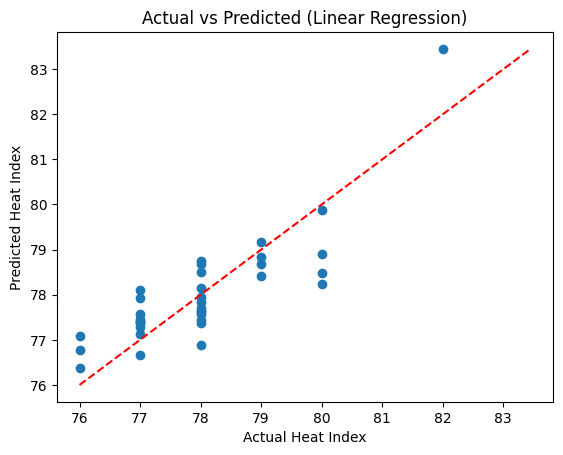

In [ ]:
#Actual vs Predicted Plot

plt.scatter(y_test, y_pred)

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", color="red")

plt.xlabel("Actual Heat Index")
plt.ylabel("Predicted Heat Index")
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

==================================================================

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,48.028242
1,impervious_pct,1.914605
2,tree_canopy_pct,1.731391
3,job_density,14.806691
4,commercial_construction,15.604170


In [ ]:
#Loop to Find Best Model
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

features = [
    "impervious_pct",
    "tree_canopy_pct",
    "housing_density",
    "job_density",
    "commercial_construction",
    "tree_to_impervious"
]

results = []

for r in range(2, len(features) + 1):   # tries 2 features up to all features
    for combo in combinations(features, r):

        X_temp = df[list(combo)]
        y = df["heat_index"]

        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y, test_size=0.25, random_state=2302
        )

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("linear", LinearRegression())
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "features": combo,
            "num_features": len(combo),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
).head(5)

,features,num_features,RMSE,MAE,R2
38,"(impervious_pct, tree_canopy_pct, job_density,...",4,0.723701,0.586863,0.683948
44,"(impervious_pct, job_density, commercial_const...",4,0.738934,0.581194,0.670503
50,"(impervious_pct, tree_canopy_pct, housing_dens...",5,0.741006,0.600375,0.668653
15,"(impervious_pct, tree_canopy_pct, housing_dens...",3,0.749840,0.594171,0.660705
34,"(job_density, commercial_construction, tree_to...",3,0.762582,0.602265,0.649076


In [ ]:
#Find Best Model

best_model = results_df.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
).iloc[0]

best_model

,38
features,"(impervious_pct, tree_canopy_pct, job_density,..."
num_features,4
RMSE,0.723701
MAE,0.586863
R2,0.683948


In [ ]:
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred))
mae_linear = mean_absolute_error(y_test, y_pred)
r2_linear = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("RMSE:", rmse_linear)
print("MAE:", mae_linear)
print("R²:", r2_linear)

Linear Regression Performance
RMSE: 0.7845911712326306
MAE: 0.6339109841115329
R²: 0.628527315359195


#Regression - KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Rebuild kNN model
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=3))
])

# Fit using the SAME training data
knn_model.fit(X_train, y_train)

# Predict using the SAME X_test
y_pred_knn = knn_model.predict(X_test)

# Check lengths
print(len(y_test), len(y_pred_knn))

# Evaluate
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("kNN Regression Performance")
print("RMSE:", rmse_knn)
print("MAE:", mae_knn)
print("R²:", r2_knn)

35 35
kNN Regression Performance
RMSE: 0.8855094489202155
MAE: 0.6952380952380943
R²: 0.5268199233716477


In [ ]:
#Tune k

results = []

for k in range(1, 30):
    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)

    temp_rmse = np.sqrt(mean_squared_error(y_test, preds))
    temp_r2 = r2_score(y_test, preds)

    results.append((k, temp_rmse, temp_r2))

results_df = pd.DataFrame(results, columns=["k", "RMSE", "R2"])
results_df.sort_values(by="RMSE").head()

,k,RMSE,R2
2,3,0.885509,0.526820
14,15,0.894427,0.517241
11,12,0.899405,0.511853
10,11,0.901003,0.510117
16,17,0.902296,0.508710


In [ ]:
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

In [233]:
comparison = pd.DataFrame([
    ["Linear Regression", rmse_linear, mae_linear, r2_linear],
    ["kNN Regression", rmse_knn, mae_knn, r2_knn]
], columns=["Model", "RMSE", "MAE", "R2"])

comparison.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
0,Linear Regression,0.784591,0.633911,0.628527
1,kNN Regression,0.885509,0.695238,0.526820


#Regression - GAMs Regression

In [ ]:
!pip install pygam

In [236]:
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Scale data
gam_scaler = StandardScaler()
X_train_gam = gam_scaler.fit_transform(X_train)
X_test_gam = gam_scaler.transform(X_test)

# Fit GAM
gam_model = LinearGAM(s(0) + s(1) + s(2) + s(3))
gam_model.fit(X_train_gam, y_train)

# Predict on SCALED test data
y_pred_gam = gam_model.predict(X_test_gam)

# Evaluate
rmse_gam = np.sqrt(mean_squared_error(y_test, y_pred_gam))
mae_gam = mean_absolute_error(y_test, y_pred_gam)
r2_gam = r2_score(y_test, y_pred_gam)

print("GAM Regression Performance")
print("RMSE:", rmse_gam)
print("MAE:", mae_gam)
print("R²:", r2_gam)

GAM Regression Performance
RMSE: 8.878163359863187
MAE: 2.5669756721394004
R²: -46.564870044044866


In [237]:
comparison = pd.DataFrame([
    ["Linear Regression", rmse_linear, mae_linear, r2_linear],
    ["kNN Regression", rmse_knn, mae_knn, r2_knn],
    ["GAM Regression", rmse_gam, mae_gam, r2_gam]
], columns=["Model", "RMSE", "MAE", "R2"])

comparison.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
0,Linear Regression,0.784591,0.633911,0.628527
1,kNN Regression,0.885509,0.695238,0.526820
2,GAM Regression,8.878163,2.566976,-46.564870


  lam=0.001  → R²=-44.6130
  lam=0.01   → R²=-42.9773
  lam=0.1    → R²=-344.3362
  lam=0.5    → R²=-134.9669
  lam=1      → R²=-13.4771
  lam=5      → R²=-12.3506
  lam=10     → R²=-23.9605
  lam=50     → R²=-13.9821
  lam=100    → R²=-20.9150

Best lambda: 5 | Best R²: -12.3506

GAM Regression Performance
  RMSE : 4.7036
  MAE  : 1.5996
  R²   : -12.3506


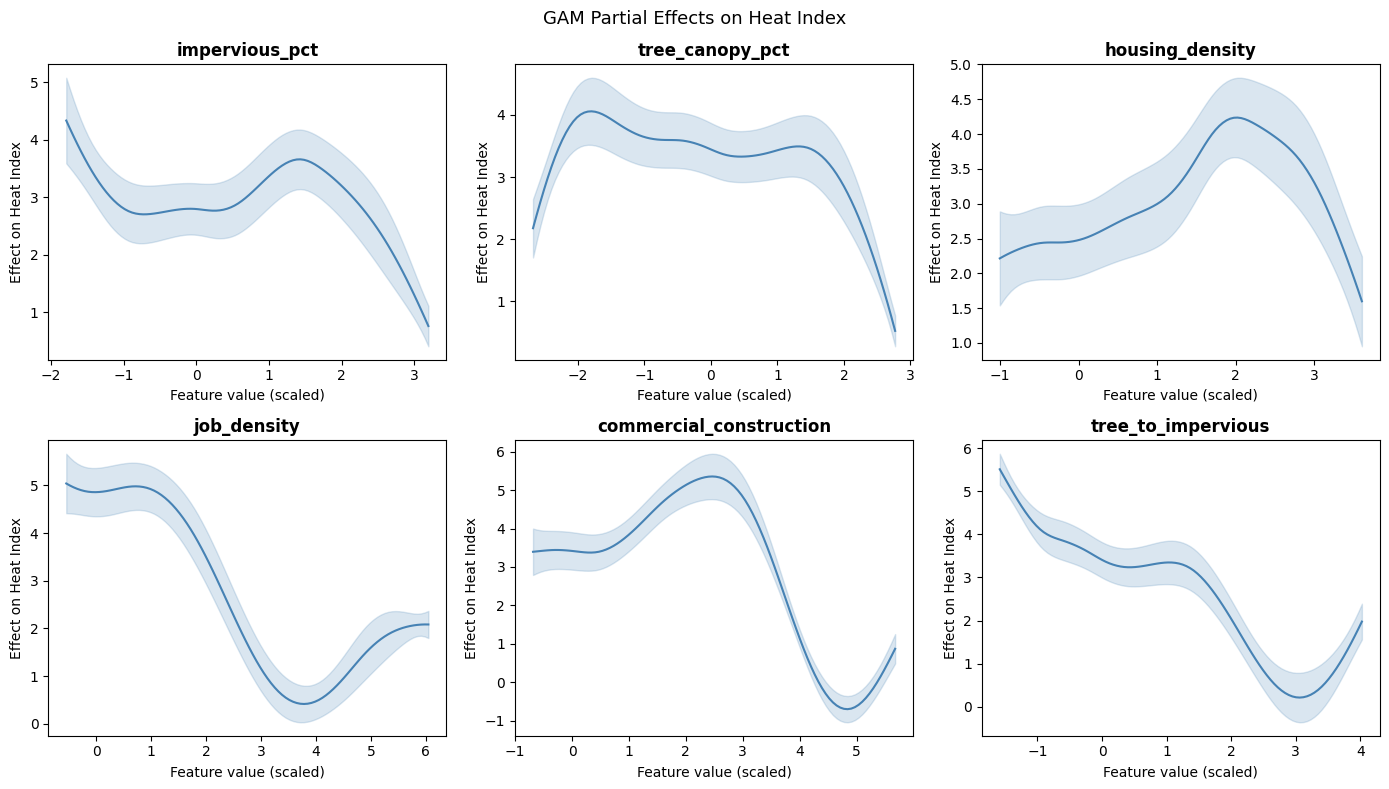

In [246]:
# ============================================================
# GAM — FULLY FIXED VERSION
# ============================================================
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Scale
gam_scaler = StandardScaler()
X_train_gam = gam_scaler.fit_transform(X_train)
X_test_gam  = gam_scaler.transform(X_test)

# Get number of features dynamically
n_features = X_train.shape[1]

# Try a range of lambda values manually and pick best
best_r2  = -999
best_lam = None
best_gam = None

for lam in [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]:
    terms = s(0, lam=lam)
    for i in range(1, n_features):
        terms += s(i, lam=lam)
    gam_try = LinearGAM(terms)
    gam_try.fit(X_train_gam, y_train)
    r2_try = r2_score(y_test, gam_try.predict(X_test_gam))
    print(f"  lam={lam:<6} → R²={r2_try:.4f}")
    if r2_try > best_r2:
        best_r2  = r2_try
        best_lam = lam
        best_gam = gam_try

print(f"\nBest lambda: {best_lam} | Best R²: {best_r2:.4f}")

# Final evaluation with best GAM
y_pred_gam = best_gam.predict(X_test_gam)
rmse_gam = np.sqrt(mean_squared_error(y_test, y_pred_gam))
mae_gam  = mean_absolute_error(y_test, y_pred_gam)
r2_gam   = r2_score(y_test, y_pred_gam)

print("\nGAM Regression Performance")
print(f"  RMSE : {rmse_gam:.4f}")
print(f"  MAE  : {mae_gam:.4f}")
print(f"  R²   : {r2_gam:.4f}")

# ── Partial Effects Plot ──────────────────────────────────────
feature_names = list(X_train.columns)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (ax, fname) in enumerate(zip(axes.flatten(), feature_names)):
    XX = best_gam.generate_X_grid(term=i)
    pdep, confi = best_gam.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, color="steelblue")
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                    alpha=0.2, color="steelblue")
    ax.set_title(fname, fontweight="bold")
    ax.set_xlabel("Feature value (scaled)")
    ax.set_ylabel("Effect on Heat Index")
plt.suptitle("GAM Partial Effects on Heat Index", fontsize=13)
plt.tight_layout()
plt.savefig("gam_partial_effects.png", dpi=150)
plt.show()

               Model     RMSE      MAE         R²
   Linear Regression 0.784591 0.633911   0.628527
       Random Forest 0.820528 0.683457   0.593718
kNN Regression (k=3) 0.885509 0.695238   0.526820
      GAM Regression 4.703608 1.599621 -12.350644


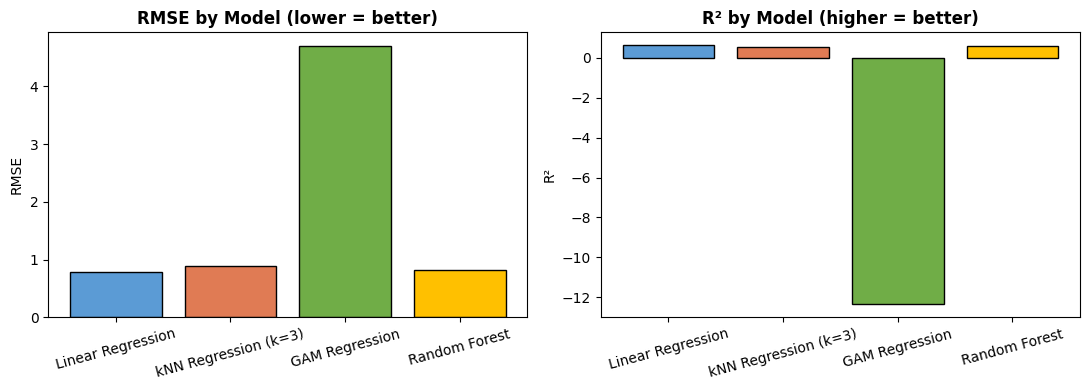

In [247]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame([
    ["Linear Regression", rmse_linear, mae_linear, r2_linear],
    ["kNN Regression (k=3)", rmse_knn,   mae_knn,   r2_knn],
    ["GAM Regression",      rmse_gam,   mae_gam,   r2_gam],
    ["Random Forest",       rmse_rf,    mae_rf,    r2_rf]
], columns=["Model", "RMSE", "MAE", "R²"])

print(comparison.sort_values(by="RMSE").to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#5b9bd5", "#e07b54", "#70ad47", "#ffc000"]
axes[0].bar(comparison["Model"], comparison["RMSE"], color=colors, edgecolor="black")
axes[0].set_title("RMSE by Model (lower = better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison["Model"], comparison["R²"], color=colors, edgecolor="black")
axes[1].set_title("R² by Model (higher = better)", fontweight="bold")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("regression_comparison.png", dpi=150)
plt.show()

#Regression - Random Forest Regression

In [250]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

# Define model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=2302
)

# Fit model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R²:", r2_rf)

Random Forest Performance
RMSE: 0.8205284663740273
MAE: 0.6834570320815223
R²: 0.5937182113007937


In [249]:
comparison = pd.DataFrame([
    ["Linear Regression", rmse_linear, mae_linear, r2_linear],
    ["kNN Regression", rmse_knn, mae_knn, r2_knn],
    ["GAM Regression", rmse_gam, mae_gam, r2_gam],
    ["Random Forest", rmse_rf, mae_rf, r2_rf]
], columns=["Model", "RMSE", "MAE", "R2"])

comparison.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
0,Linear Regression,0.784591,0.633911,0.628527
3,Random Forest,0.820528,0.683457,0.593718
1,kNN Regression,0.885509,0.695238,0.526820
2,GAM Regression,4.703608,1.599621,-12.350644


  MERGED DATASET OVERVIEW
  Rows    : 140
  Columns : 9
  Missing : 0
  Median Heat Index : 78.0°F
   NPA  heat_index  impervious_pct  tree_canopy_pct  housing_density  \
0    2        78.0            23.4             38.1           1136.0   
1    3        80.0            38.2             23.1           9704.0   
2    4        77.0            21.8             59.5            409.0   
3    5        78.0            21.5             41.0            348.0   
4    6        79.0            25.1             34.8            823.0   

   job_density  commercial_construction  tree_to_impervious  heat_risk  
0        580.0                      7.0            1.628205          0  
1      35685.0                    122.0            0.604712          1  
2        102.0                      7.0            2.729358          0  
3        205.0                      2.0            1.906977          0  
4        895.0                     12.0            1.386454          1  

Train: 105 rows | Test: 35 ro

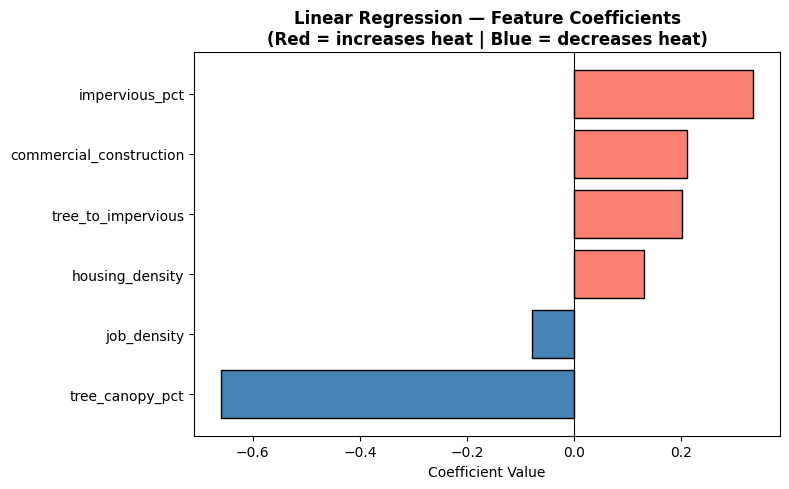

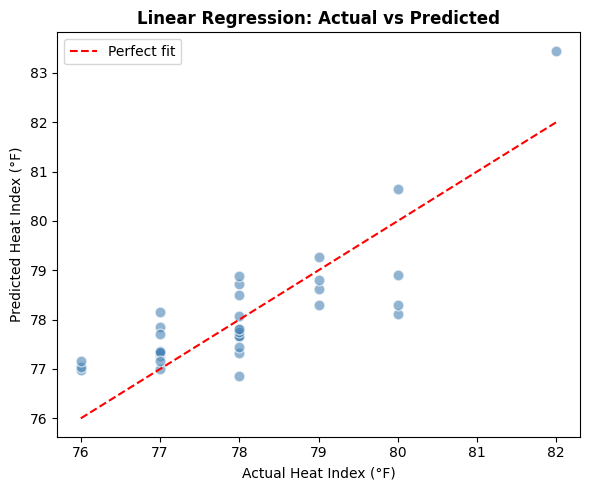

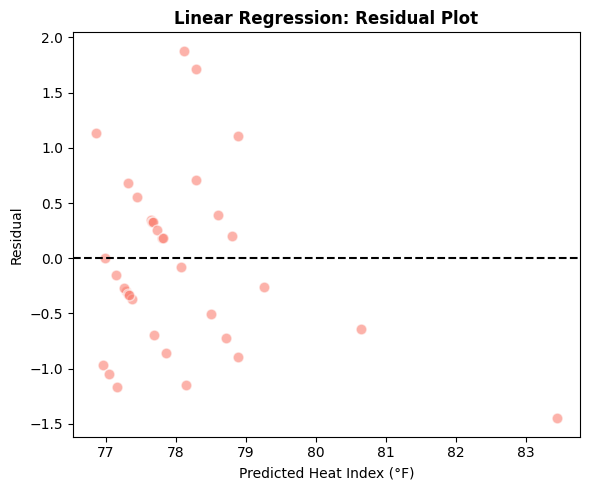


Searching best feature subset...

Top 5 Feature Subsets:
                                                                                features  num_features     RMSE      MAE       R2
                 (impervious_pct, tree_canopy_pct, job_density, commercial_construction)             4 0.723701 0.586863 0.683948
              (impervious_pct, job_density, commercial_construction, tree_to_impervious)             4 0.738934 0.581194 0.670503
(impervious_pct, tree_canopy_pct, housing_density, job_density, commercial_construction)             5 0.741006 0.600375 0.668653
                                      (impervious_pct, tree_canopy_pct, housing_density)             3 0.749840 0.594171 0.660705
                              (job_density, commercial_construction, tree_to_impervious)             3 0.762582 0.602265 0.649076

  METHOD 2: kNN REGRESSION

Best k = 3
 k     RMSE      MAE       R2
 3 0.885509 0.695238 0.526820
15 0.894427 0.685714 0.517241
12 0.899405 0.707143 0.511853
11

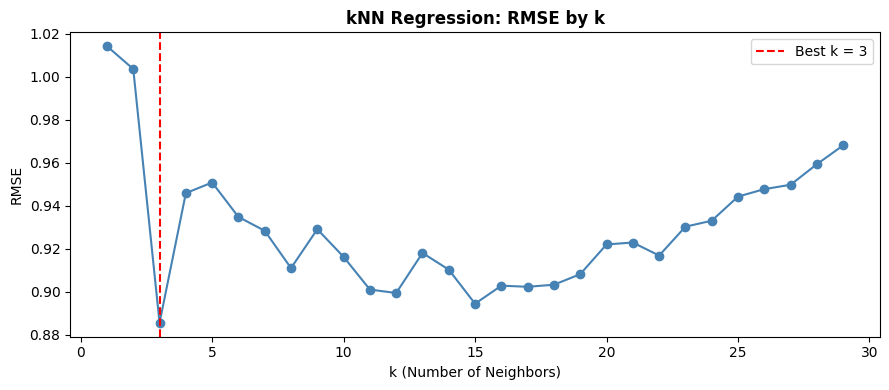


kNN (k=3) Performance
  RMSE : 0.8855
  MAE  : 0.6952
  R²   : 0.5268


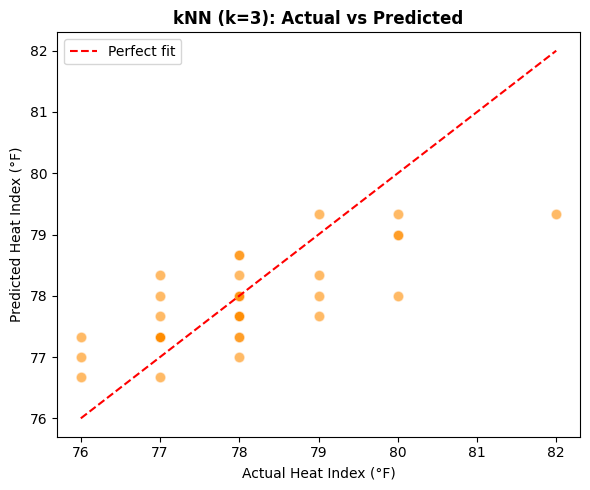


  METHOD 3: GAM REGRESSION
Tuning lambda...
  lam=0.001  → R²=-44.6130
  lam=0.01   → R²=-42.9773
  lam=0.1    → R²=-344.3362
  lam=0.5    → R²=-134.9669
  lam=1      → R²=-13.4771
  lam=5      → R²=-12.3506
  lam=10     → R²=-23.9605
  lam=50     → R²=-13.9821
  lam=100    → R²=-20.9150

Best lambda : 5
  RMSE : 4.7036
  MAE  : 1.5996
  R²   : -12.3506


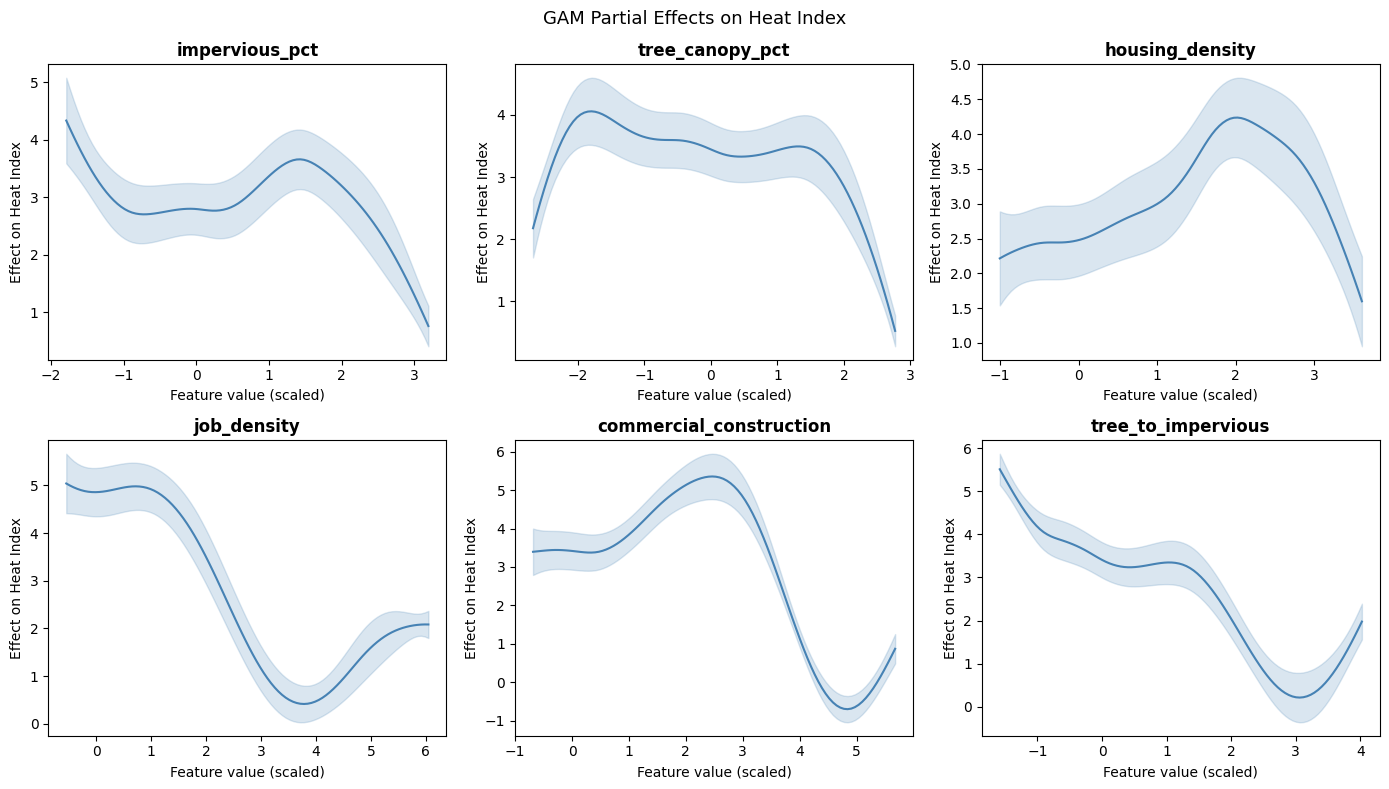

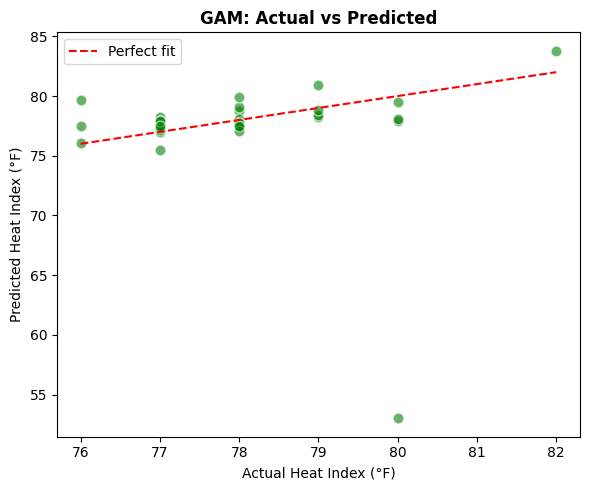


  METHOD 4: RANDOM FOREST
  RMSE : 0.8205
  MAE  : 0.6835
  R²   : 0.5937


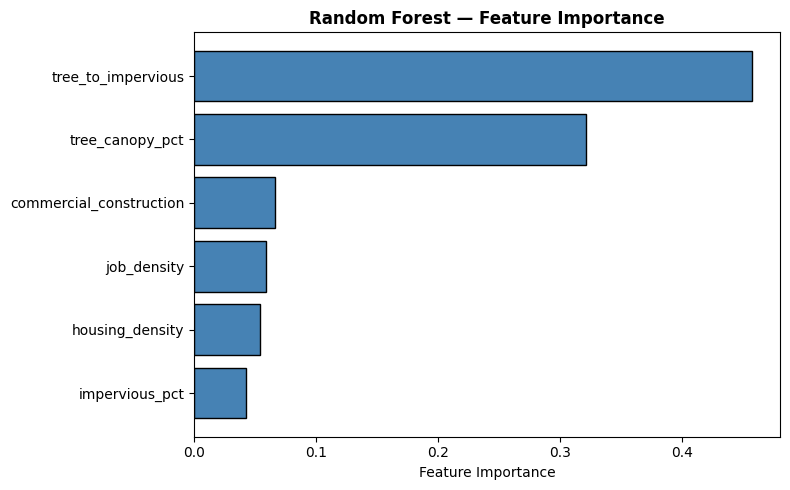


   REGRESSION MODEL COMPARISON — FINAL SUMMARY
            Model     RMSE      MAE         R²
Linear Regression 0.784591 0.633911   0.628527
    Random Forest 0.820528 0.683457   0.593718
        kNN (k=3) 0.885509 0.695238   0.526820
              GAM 4.703608 1.599621 -12.350644

✅ Best Model : Linear Regression
   RMSE       : 0.7846
   R²         : 0.6285


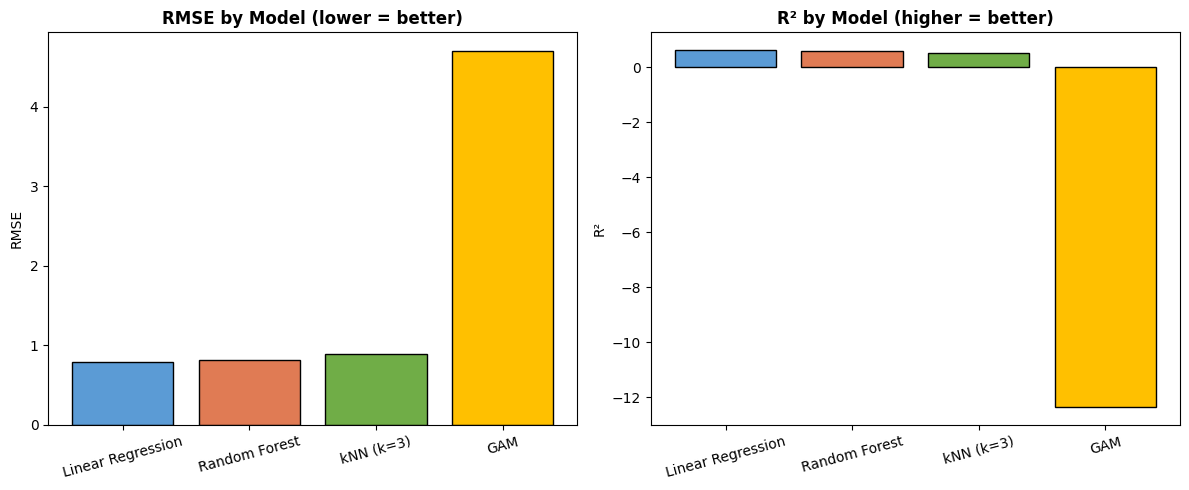

In [251]:
# ============================================================
# FULL REGRESSION MODEL — URBAN HEAT ISLAND ANALYSIS
# ============================================================

# ── STEP 1: INSTALL & IMPORTS ────────────────────────────────
!pip install pygam -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations
from pygam import LinearGAM, s

# ── STEP 2: LOAD RAW DATA ────────────────────────────────────
heat         = pd.read_csv("/content/Heat Index.csv")
impervious   = pd.read_csv("/content/Impervious Surface.csv")
tree         = pd.read_csv("/content/Tree Canopy.csv")
housing      = pd.read_csv("/content/Housing Density.csv")
jobs         = pd.read_csv("/content/Job Density.csv")
construction = pd.read_csv("/content/Commercial Construction.csv")

# ── STEP 3: CLEAN NUMERIC DATA ───────────────────────────────
def clean_numeric(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace('"', "", regex=False)
        .replace(["--", "-", "", "nan", "NaN", "N/A", "NA"], np.nan)
        .astype(float)
    )

heat_clean             = heat[["NPA", "2024"]].copy()
heat_clean["heat_index"] = clean_numeric(heat_clean["2024"])
heat_clean             = heat_clean[["NPA", "heat_index"]]

imperv_clean              = impervious[["NPA", "2023"]].copy()
imperv_clean["impervious_pct"] = clean_numeric(imperv_clean["2023"])
imperv_clean              = imperv_clean[["NPA", "impervious_pct"]]

tree_clean                 = tree[["NPA", "2023"]].copy()
tree_clean["tree_canopy_pct"] = clean_numeric(tree_clean["2023"])
tree_clean                 = tree_clean[["NPA", "tree_canopy_pct"]]

housing_clean                = housing[["NPA", "2023 Raw"]].copy()
housing_clean["housing_density"] = clean_numeric(housing_clean["2023 Raw"])
housing_clean                = housing_clean[["NPA", "housing_density"]]

jobs_clean               = jobs[["NPA", "2022 Raw"]].copy()
jobs_clean["job_density"] = clean_numeric(jobs_clean["2022 Raw"])
jobs_clean               = jobs_clean[["NPA", "job_density"]]

const_clean                       = construction[["NPA", "2023 Raw"]].copy()
const_clean["commercial_construction"] = clean_numeric(const_clean["2023 Raw"])
const_clean                       = const_clean[["NPA", "commercial_construction"]]

# ── STEP 4: MERGE USING SQLITE (DATABASE EVIDENCE) ───────────
conn = sqlite3.connect("uhi_project.db")
heat_clean.to_sql("heat",         conn, if_exists="replace", index=False)
imperv_clean.to_sql("impervious", conn, if_exists="replace", index=False)
tree_clean.to_sql("tree",         conn, if_exists="replace", index=False)
housing_clean.to_sql("housing",   conn, if_exists="replace", index=False)
jobs_clean.to_sql("jobs",         conn, if_exists="replace", index=False)
const_clean.to_sql("construction",conn, if_exists="replace", index=False)

query = """
SELECT
    h.NPA,
    h.heat_index,
    i.impervious_pct,
    t.tree_canopy_pct,
    ho.housing_density,
    j.job_density,
    c.commercial_construction
FROM heat h
INNER JOIN impervious i   ON h.NPA = i.NPA
INNER JOIN tree t         ON h.NPA = t.NPA
INNER JOIN housing ho     ON h.NPA = ho.NPA
INNER JOIN jobs j         ON h.NPA = j.NPA
INNER JOIN construction c ON h.NPA = c.NPA
"""
df = pd.read_sql_query(query, conn)
conn.close()

# ── STEP 5: FEATURE ENGINEERING ──────────────────────────────
df = df.dropna()
df["tree_to_impervious"] = df["tree_canopy_pct"] / df["impervious_pct"]
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Classification target (used later)
median_heat        = df["heat_index"].median()
df["heat_risk"]    = (df["heat_index"] > median_heat).astype(int)

print("=" * 50)
print("  MERGED DATASET OVERVIEW")
print("=" * 50)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"  Missing : {df.isnull().sum().sum()}")
print(f"  Median Heat Index : {median_heat}°F")
print("=" * 50)
print(df.head())

# ── STEP 6: DEFINE FEATURES & TARGET ─────────────────────────
FEATURES = [
    "impervious_pct",
    "tree_canopy_pct",
    "housing_density",
    "job_density",
    "commercial_construction",
    "tree_to_impervious"
]

X = df[FEATURES]
y = df["heat_index"]

# ── STEP 7: TRAIN / TEST SPLIT ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2302
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# ============================================================
# ── METHOD 1: LINEAR REGRESSION ─────────────────────────────
# ============================================================
print("\n" + "=" * 50)
print("  METHOD 1: LINEAR REGRESSION")
print("=" * 50)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression())
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

# Statsmodels full summary
X_sm     = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
print("\n", model_sm.summary())

# VIF Table
X_vif    = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"]     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
print("\nVIF Table:")
print(vif_data.to_string(index=False))

# Coefficients bar chart
coef_df = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": lr_pipe.named_steps["lr"].coef_
}).sort_values("Coefficient", ascending=True)

colors_coef = ["salmon" if c > 0 else "steelblue"
               for c in coef_df["Coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"],
         color=colors_coef, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Linear Regression — Feature Coefficients\n"
          "(Red = increases heat | Blue = decreases heat)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150)
plt.show()

# Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6,
            color="steelblue", edgecolors="white", s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=1.5, label="Perfect fit")
plt.xlabel("Actual Heat Index (°F)")
plt.ylabel("Predicted Heat Index (°F)")
plt.title("Linear Regression: Actual vs Predicted", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("lr_actual_vs_predicted.png", dpi=150)
plt.show()

# Residual plot
residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(6, 5))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.6,
            color="salmon", edgecolors="white", s=60)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Heat Index (°F)")
plt.ylabel("Residual")
plt.title("Linear Regression: Residual Plot", fontweight="bold")
plt.tight_layout()
plt.savefig("lr_residuals.png", dpi=150)
plt.show()

# Best feature subset search
print("\nSearching best feature subset...")
subset_results = []
for r in range(2, len(FEATURES) + 1):
    for combo in combinations(FEATURES, r):
        X_temp = df[list(combo)]
        Xtr, Xte, ytr, yte = train_test_split(
            X_temp, y, test_size=0.25, random_state=2302)
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("lr", LinearRegression())])
        pipe.fit(Xtr, ytr)
        preds = pipe.predict(Xte)
        subset_results.append({
            "features":     combo,
            "num_features": len(combo),
            "RMSE":         np.sqrt(mean_squared_error(yte, preds)),
            "MAE":          mean_absolute_error(yte, preds),
            "R2":           r2_score(yte, preds)
        })

subset_df = pd.DataFrame(subset_results).sort_values(
    by=["R2", "RMSE"], ascending=[False, True])
print("\nTop 5 Feature Subsets:")
print(subset_df.head().to_string(index=False))

# ============================================================
# ── METHOD 2: kNN REGRESSION ────────────────────────────────
# ============================================================
print("\n" + "=" * 50)
print("  METHOD 2: kNN REGRESSION")
print("=" * 50)

# Tune k
k_results = []
for k in range(1, 30):
    knn = Pipeline([("scaler", StandardScaler()),
                    ("knn",    KNeighborsRegressor(n_neighbors=k))])
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    k_results.append({
        "k":    k,
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE":  mean_absolute_error(y_test, preds),
        "R2":   r2_score(y_test, preds)
    })

k_df   = pd.DataFrame(k_results)
best_k = k_df.loc[k_df["RMSE"].idxmin(), "k"]
print(f"\nBest k = {best_k}")
print(k_df.sort_values("RMSE").head(5).to_string(index=False))

# k selection plot
plt.figure(figsize=(9, 4))
plt.plot(k_df["k"], k_df["RMSE"], marker="o",
         color="steelblue", linewidth=1.5)
plt.axvline(best_k, color="red", linestyle="--",
            label=f"Best k = {best_k}")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("RMSE")
plt.title("kNN Regression: RMSE by k", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("knn_k_selection.png", dpi=150)
plt.show()

# Final kNN model
knn_best = Pipeline([("scaler", StandardScaler()),
                     ("knn",    KNeighborsRegressor(n_neighbors=best_k))])
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print(f"\nkNN (k={best_k}) Performance")
print(f"  RMSE : {rmse_knn:.4f}")
print(f"  MAE  : {mae_knn:.4f}")
print(f"  R²   : {r2_knn:.4f}")

# Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.6,
            color="darkorange", edgecolors="white", s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=1.5, label="Perfect fit")
plt.xlabel("Actual Heat Index (°F)")
plt.ylabel("Predicted Heat Index (°F)")
plt.title(f"kNN (k={best_k}): Actual vs Predicted", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("knn_actual_vs_predicted.png", dpi=150)
plt.show()

# ============================================================
# ── METHOD 3: GAM ───────────────────────────────────────────
# ============================================================
print("\n" + "=" * 50)
print("  METHOD 3: GAM REGRESSION")
print("=" * 50)

gam_scaler  = StandardScaler()
X_train_gam = gam_scaler.fit_transform(X_train)
X_test_gam  = gam_scaler.transform(X_test)
n_features  = X_train.shape[1]

# Manually tune lambda
best_r2_gam  = -999
best_lam     = None
best_gam     = None

print("Tuning lambda...")
for lam in [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]:
    terms = s(0, lam=lam)
    for i in range(1, n_features):
        terms += s(i, lam=lam)
    gam_try = LinearGAM(terms)
    gam_try.fit(X_train_gam, y_train)
    r2_try = r2_score(y_test, gam_try.predict(X_test_gam))
    print(f"  lam={lam:<6} → R²={r2_try:.4f}")
    if r2_try > best_r2_gam:
        best_r2_gam = r2_try
        best_lam    = lam
        best_gam    = gam_try

y_pred_gam = best_gam.predict(X_test_gam)
rmse_gam   = np.sqrt(mean_squared_error(y_test, y_pred_gam))
mae_gam    = mean_absolute_error(y_test, y_pred_gam)
r2_gam     = r2_score(y_test, y_pred_gam)

print(f"\nBest lambda : {best_lam}")
print(f"  RMSE : {rmse_gam:.4f}")
print(f"  MAE  : {mae_gam:.4f}")
print(f"  R²   : {r2_gam:.4f}")

# GAM Partial Effects
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (ax, fname) in enumerate(zip(axes.flatten(), FEATURES)):
    XX   = best_gam.generate_X_grid(term=i)
    pdep, confi = best_gam.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, color="steelblue")
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                    alpha=0.2, color="steelblue")
    ax.set_title(fname, fontweight="bold")
    ax.set_xlabel("Feature value (scaled)")
    ax.set_ylabel("Effect on Heat Index")
plt.suptitle("GAM Partial Effects on Heat Index", fontsize=13)
plt.tight_layout()
plt.savefig("gam_partial_effects.png", dpi=150)
plt.show()

# Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_gam, alpha=0.6,
            color="green", edgecolors="white", s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=1.5, label="Perfect fit")
plt.xlabel("Actual Heat Index (°F)")
plt.ylabel("Predicted Heat Index (°F)")
plt.title("GAM: Actual vs Predicted", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("gam_actual_vs_predicted.png", dpi=150)
plt.show()

# ============================================================
# ── METHOD 4: RANDOM FOREST ─────────────────────────────────
# ============================================================
print("\n" + "=" * 50)
print("  METHOD 4: RANDOM FOREST")
print("=" * 50)

rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=2302)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

# Feature Importance
fi_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"],
         color="steelblue", edgecolor="black")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

# ============================================================
# ── FINAL MODEL COMPARISON ───────────────────────────────────
# ============================================================
print("\n" + "=" * 55)
print("   REGRESSION MODEL COMPARISON — FINAL SUMMARY")
print("=" * 55)

comparison = pd.DataFrame([
    ["Linear Regression",       rmse_lr,  mae_lr,  r2_lr],
    [f"kNN (k={best_k})",       rmse_knn, mae_knn, r2_knn],
    ["GAM",                     rmse_gam, mae_gam, r2_gam],
    ["Random Forest",           rmse_rf,  mae_rf,  r2_rf],
], columns=["Model", "RMSE", "MAE", "R²"])

comparison = comparison.sort_values("RMSE").reset_index(drop=True)
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]["Model"]
best_rmse       = comparison.iloc[0]["RMSE"]
best_r2         = comparison.iloc[0]["R²"]
print(f"\n✅ Best Model : {best_model_name}")
print(f"   RMSE       : {best_rmse:.4f}")
print(f"   R²         : {best_r2:.4f}")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#5b9bd5", "#e07b54", "#70ad47", "#ffc000"]

axes[0].bar(comparison["Model"], comparison["RMSE"],
            color=colors, edgecolor="black")
axes[0].set_title("RMSE by Model (lower = better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison["Model"], comparison["R²"],
            color=colors, edgecolor="black")
axes[1].set_title("R² by Model (higher = better)", fontweight="bold")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("regression_comparison.png", dpi=150)
plt.show()

#Classification -  Overview

  CLASSIFICATION TARGET — CLASS BALANCE
  Median Heat Index : 78.0°F
  Low Risk  (0) : 107 NPAs (76.4%)
  High Risk (1) : 33 NPAs (23.6%)


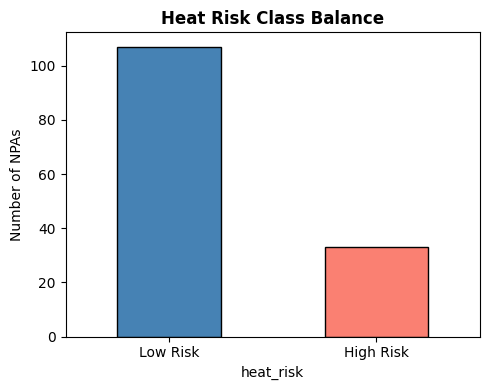


Train: 105 rows | Test: 35 rows
Train High Risk: 25 | Test High Risk: 8


In [254]:
# ============================================================
# FULL CLASSIFICATION MODEL — URBAN HEAT ISLAND ANALYSIS
# ============================================================

# ── STEP 1: IMPORTS ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
from pygam import LogisticGAM, s
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

# ── STEP 2: DEFINE TARGET & FEATURES ─────────────────────────
# Target: 1 = High Risk (above median heat index), 0 = Low Risk
print("=" * 55)
print("  CLASSIFICATION TARGET — CLASS BALANCE")
print("=" * 55)
print(f"  Median Heat Index : {median_heat}°F")
counts = df["heat_risk"].value_counts()
pcts   = df["heat_risk"].value_counts(normalize=True) * 100
print(f"  Low Risk  (0) : {counts[0]} NPAs ({pcts[0]:.1f}%)")
print(f"  High Risk (1) : {counts[1]} NPAs ({pcts[1]:.1f}%)")
print("=" * 55)

# Class balance bar chart
plt.figure(figsize=(5, 4))
df["heat_risk"].map({0:"Low Risk", 1:"High Risk"}).value_counts().plot(
    kind="bar", color=["steelblue","salmon"], edgecolor="black")
plt.title("Heat Risk Class Balance", fontweight="bold")
plt.ylabel("Number of NPAs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()

# ── STEP 3: TRAIN / TEST SPLIT ───────────────────────────────
X_c = df[FEATURES]
y_c = df["heat_risk"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.25, random_state=2302, stratify=y_c
)

scaler_c     = StandardScaler()
X_train_csc  = scaler_c.fit_transform(X_train_c)
X_test_csc   = scaler_c.transform(X_test_c)

print(f"\nTrain: {X_train_c.shape[0]} rows | Test: {X_test_c.shape[0]} rows")
print(f"Train High Risk: {y_train_c.sum()} | Test High Risk: {y_test_c.sum()}")

#Classification - LOGISTIC REGRESSION


  METHOD 1: LOGISTIC REGRESSION
  Accuracy : 0.8857
  AUC-ROC  : 0.9167

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.96      0.93        27
   High Risk       0.83      0.62      0.71         8

    accuracy                           0.89        35
   macro avg       0.86      0.79      0.82        35
weighted avg       0.88      0.89      0.88        35

                           Logit Regression Results                           
Dep. Variable:              heat_risk   No. Observations:                  140
Model:                          Logit   Df Residuals:                      133
Method:                           MLE   Df Model:                            6
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.5244
Time:                        19:26:41   Log-Likelihood:                -36.358
converged:                       True   LL-Null:                       -76.453
Covariance Type:     

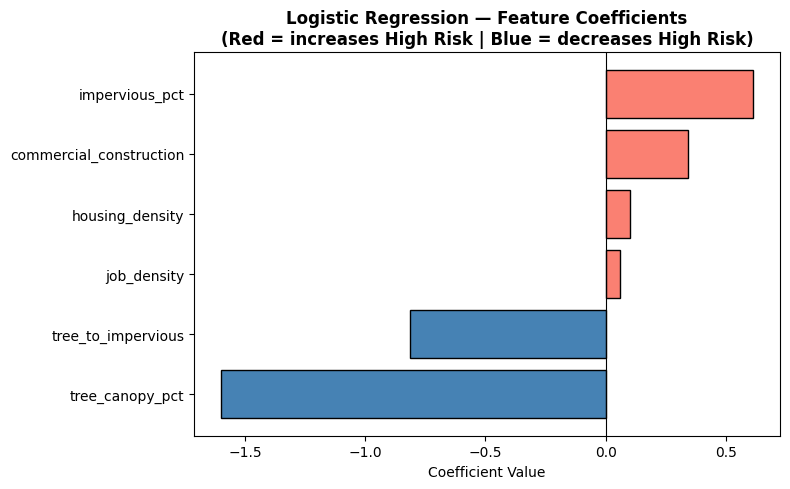

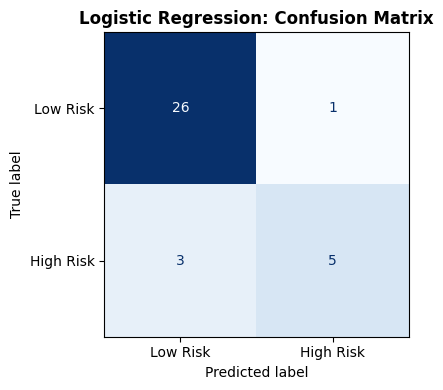

In [255]:
# ============================================================
# ── METHOD 1: LOGISTIC REGRESSION ───────────────────────────
# ============================================================
print("\n" + "=" * 55)
print("  METHOD 1: LOGISTIC REGRESSION")
print("=" * 55)

log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(random_state=2302, max_iter=1000))
])
log_pipe.fit(X_train_c, y_train_c)
y_pred_log   = log_pipe.predict(X_test_c)
y_prob_log   = log_pipe.predict_proba(X_test_c)[:, 1]

acc_log  = accuracy_score(y_test_c, y_pred_log)
auc_log  = roc_auc_score(y_test_c, y_prob_log)

print(f"  Accuracy : {acc_log:.4f}")
print(f"  AUC-ROC  : {auc_log:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test_c, y_pred_log,
      target_names=["Low Risk", "High Risk"]))

# Statsmodels Logistic Summary
X_sm_c     = sm.add_constant(X_c)
log_sm     = sm.Logit(y_c, X_sm_c).fit(disp=0)
print(log_sm.summary())

# Coefficients bar chart
log_coef = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": log_pipe.named_steps["lr"].coef_[0]
}).sort_values("Coefficient", ascending=True)

colors_log = ["salmon" if c > 0 else "steelblue"
              for c in log_coef["Coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(log_coef["Feature"], log_coef["Coefficient"],
         color=colors_log, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression — Feature Coefficients\n"
          "(Red = increases High Risk | Blue = decreases High Risk)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("log_coefficients.png", dpi=150)
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_log),
    display_labels=["Low Risk", "High Risk"]
).plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Logistic Regression: Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("log_confusion_matrix.png", dpi=150)
plt.show()


#Classification - kNN CLASSIFICATION


  METHOD 2: kNN CLASSIFICATION

Best k = 8
 k  Accuracy      AUC
 9  0.885714 0.923611
 8  0.885714 0.925926
13  0.885714 0.932870
15  0.885714 0.925926
14  0.885714 0.930556


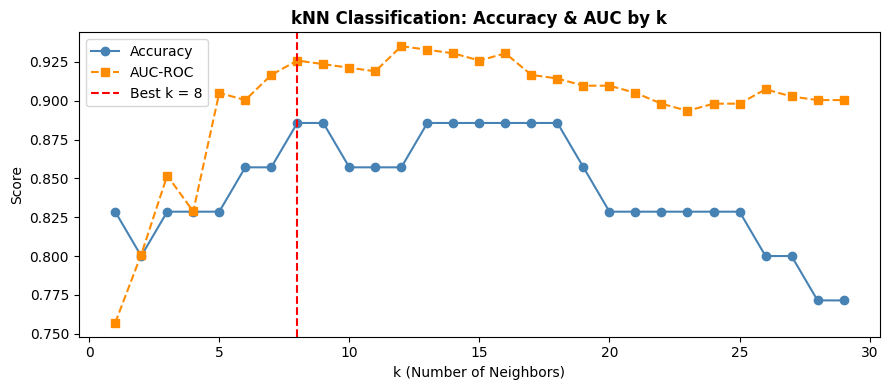


kNN (k=8) Performance
  Accuracy : 0.8857
  AUC-ROC  : 0.9259

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.96      0.93        27
   High Risk       0.83      0.62      0.71         8

    accuracy                           0.89        35
   macro avg       0.86      0.79      0.82        35
weighted avg       0.88      0.89      0.88        35



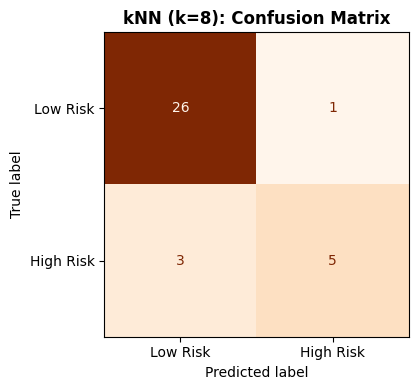

In [256]:
# ============================================================
# ── METHOD 2: kNN CLASSIFICATION ────────────────────────────
# ============================================================
print("\n" + "=" * 55)
print("  METHOD 2: kNN CLASSIFICATION")
print("=" * 55)

# Tune k
k_results_c = []
for k in range(1, 30):
    knn_c = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k))
    ])
    knn_c.fit(X_train_c, y_train_c)
    preds_c = knn_c.predict(X_test_c)
    k_results_c.append({
        "k":        k,
        "Accuracy": accuracy_score(y_test_c, preds_c),
        "AUC":      roc_auc_score(y_test_c,
                    knn_c.predict_proba(X_test_c)[:, 1])
    })

k_df_c   = pd.DataFrame(k_results_c)
best_k_c = k_df_c.loc[k_df_c["Accuracy"].idxmax(), "k"]
print(f"\nBest k = {best_k_c}")
print(k_df_c.sort_values("Accuracy", ascending=False).head(5).to_string(index=False))

# k selection plot
plt.figure(figsize=(9, 4))
plt.plot(k_df_c["k"], k_df_c["Accuracy"], marker="o",
         color="steelblue", linewidth=1.5, label="Accuracy")
plt.plot(k_df_c["k"], k_df_c["AUC"], marker="s", linestyle="--",
         color="darkorange", linewidth=1.5, label="AUC-ROC")
plt.axvline(best_k_c, color="red", linestyle="--",
            label=f"Best k = {best_k_c}")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Score")
plt.title("kNN Classification: Accuracy & AUC by k", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("knn_class_k_selection.png", dpi=150)
plt.show()

# Final kNN model
knn_best_c = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=best_k_c))
])
knn_best_c.fit(X_train_c, y_train_c)
y_pred_knn_c = knn_best_c.predict(X_test_c)
y_prob_knn_c = knn_best_c.predict_proba(X_test_c)[:, 1]

acc_knn_c = accuracy_score(y_test_c, y_pred_knn_c)
auc_knn_c = roc_auc_score(y_test_c, y_prob_knn_c)

print(f"\nkNN (k={best_k_c}) Performance")
print(f"  Accuracy : {acc_knn_c:.4f}")
print(f"  AUC-ROC  : {auc_knn_c:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test_c, y_pred_knn_c,
      target_names=["Low Risk", "High Risk"]))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_knn_c),
    display_labels=["Low Risk", "High Risk"]
).plot(ax=ax, colorbar=False, cmap="Oranges")
plt.title(f"kNN (k={best_k_c}): Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("knn_class_confusion_matrix.png", dpi=150)
plt.show()

#Classification - GAM CLASSIFICATION


  METHOD 3: GAM CLASSIFICATION
Tuning lambda...
did not converge
  lam=1      → Accuracy=0.8857
did not converge
  lam=5      → Accuracy=0.8571
did not converge
  lam=10     → Accuracy=0.8571
did not converge
  lam=50     → Accuracy=0.8857
  lam=100    → Accuracy=0.8857
  lam=200    → Accuracy=0.8571
  lam=500    → Accuracy=0.8000
  lam=1000   → Accuracy=0.7714

Best lambda : 1
  Accuracy : 0.8857
  AUC-ROC  : 0.9167

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.96      0.93        27
   High Risk       0.83      0.62      0.71         8

    accuracy                           0.89        35
   macro avg       0.86      0.79      0.82        35
weighted avg       0.88      0.89      0.88        35



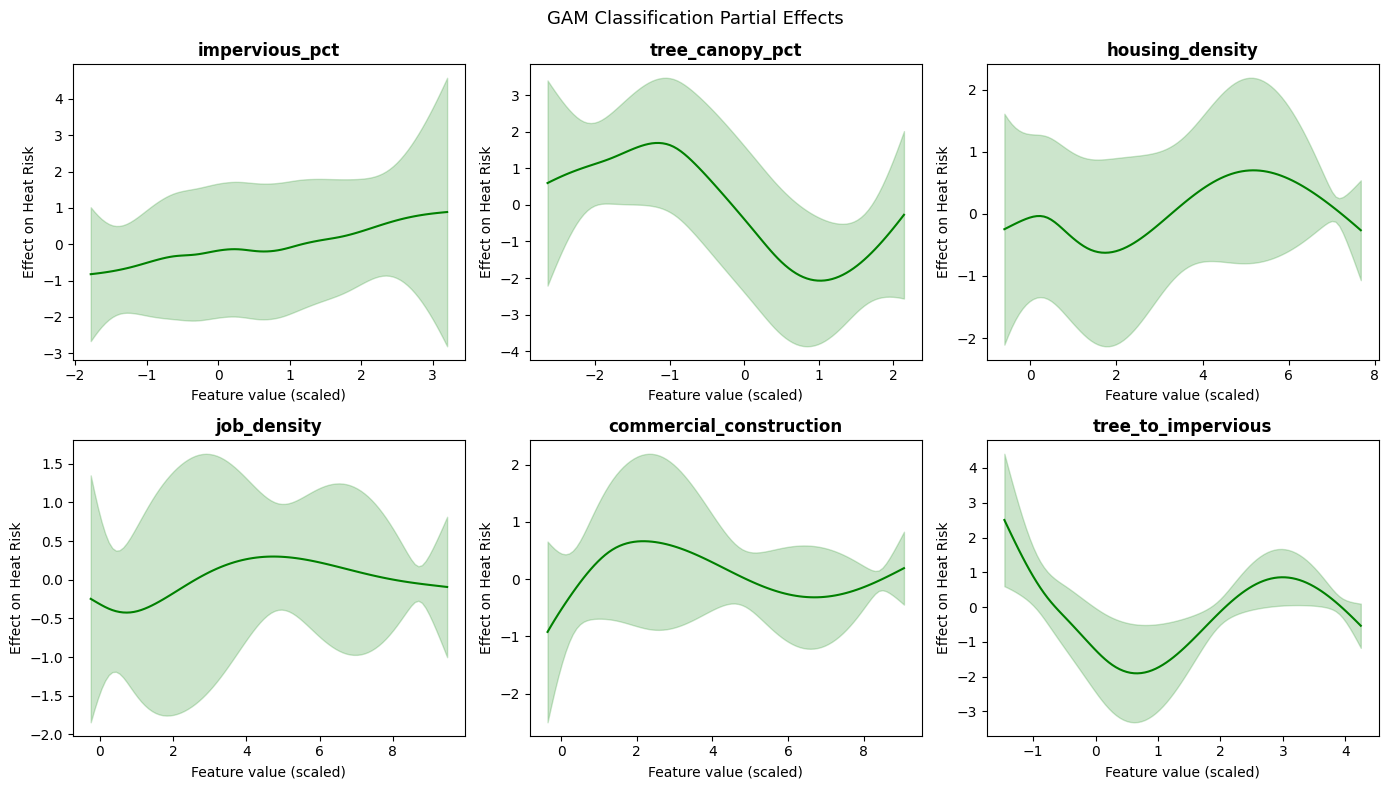

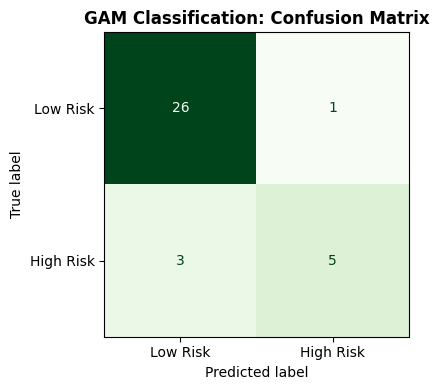

In [257]:
# ============================================================
# METHOD 3: GAM CLASSIFICATION — FIXED
# ============================================================
print("\n" + "=" * 55)
print("  METHOD 3: GAM CLASSIFICATION")
print("=" * 55)

n_features_c = X_train_c.shape[1]

best_acc_gam_c = -999
best_lam_c     = None
best_gam_c     = None

print("Tuning lambda...")
# Use higher lambda values to prevent divergence with imbalanced data
for lam in [1, 5, 10, 50, 100, 200, 500, 1000]:
    try:
        terms = s(0, lam=lam)
        for i in range(1, n_features_c):
            terms += s(i, lam=lam)
        gam_try_c = LogisticGAM(terms, max_iter=100)
        gam_try_c.fit(X_train_csc, y_train_c)
        acc_try = accuracy_score(y_test_c, gam_try_c.predict(X_test_csc))
        print(f"  lam={lam:<6} → Accuracy={acc_try:.4f}")
        if acc_try > best_acc_gam_c:
            best_acc_gam_c = acc_try
            best_lam_c     = lam
            best_gam_c     = gam_try_c
    except Exception as e:
        print(f"  lam={lam:<6} → Failed ({str(e)[:40]})")
        continue

# If GAM still fails, fall back to linear terms only
if best_gam_c is None:
    print("\n  Falling back to linear GAM terms...")
    from pygam import LogisticGAM, l
    for lam in [10, 100, 500]:
        try:
            terms = l(0, lam=lam)
            for i in range(1, n_features_c):
                terms += l(i, lam=lam)
            gam_try_c = LogisticGAM(terms, max_iter=200)
            gam_try_c.fit(X_train_csc, y_train_c)
            acc_try = accuracy_score(y_test_c, gam_try_c.predict(X_test_csc))
            print(f"  lam={lam:<6} → Accuracy={acc_try:.4f}")
            if acc_try > best_acc_gam_c:
                best_acc_gam_c = acc_try
                best_lam_c     = lam
                best_gam_c     = gam_try_c
        except Exception as e:
            print(f"  lam={lam:<6} → Failed ({str(e)[:40]})")
            continue

# Evaluate best GAM
y_pred_gam_c = best_gam_c.predict(X_test_csc)
y_prob_gam_c = best_gam_c.predict_proba(X_test_csc)

acc_gam_c = accuracy_score(y_test_c, y_pred_gam_c)
auc_gam_c = roc_auc_score(y_test_c, y_prob_gam_c)

print(f"\nBest lambda : {best_lam_c}")
print(f"  Accuracy : {acc_gam_c:.4f}")
print(f"  AUC-ROC  : {auc_gam_c:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test_c, y_pred_gam_c,
      target_names=["Low Risk", "High Risk"]))

# GAM Partial Effects
try:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for i, (ax, fname) in enumerate(zip(axes.flatten(), FEATURES)):
        XX = best_gam_c.generate_X_grid(term=i)
        pdep, confi = best_gam_c.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep, color="green")
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                        alpha=0.2, color="green")
        ax.set_title(fname, fontweight="bold")
        ax.set_xlabel("Feature value (scaled)")
        ax.set_ylabel("Effect on Heat Risk")
    plt.suptitle("GAM Classification Partial Effects", fontsize=13)
    plt.tight_layout()
    plt.savefig("gam_class_partial_effects.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"  Partial effects plot skipped: {e}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_gam_c),
    display_labels=["Low Risk", "High Risk"]
).plot(ax=ax, colorbar=False, cmap="Greens")
plt.title("GAM Classification: Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("gam_class_confusion_matrix.png", dpi=150)
plt.show()


#Classification - RANDOM FOREST CLASSIFICATION


  METHOD 4: RANDOM FOREST CLASSIFICATION
  Accuracy : 0.8571
  AUC-ROC  : 0.9074

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.89      0.93      0.91        27
   High Risk       0.71      0.62      0.67         8

    accuracy                           0.86        35
   macro avg       0.80      0.78      0.79        35
weighted avg       0.85      0.86      0.85        35



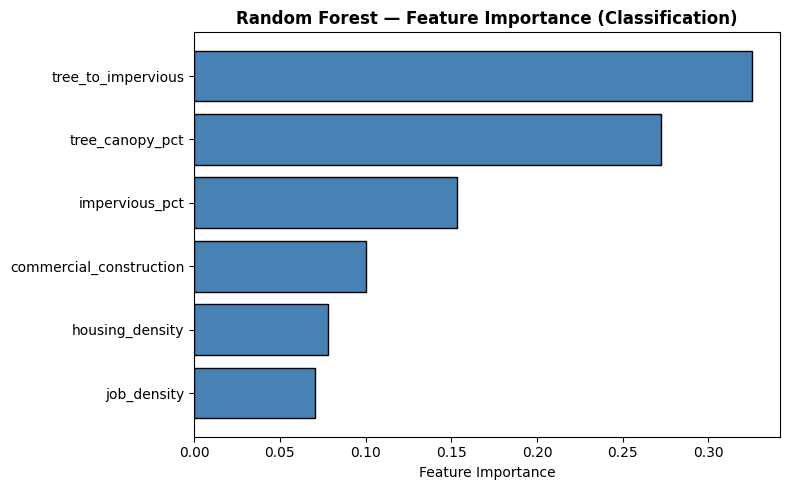

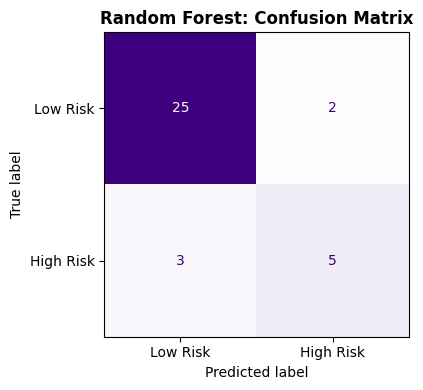

In [258]:
# ============================================================
# ── METHOD 4: RANDOM FOREST CLASSIFICATION ──────────────────
# ============================================================
print("\n" + "=" * 55)
print("  METHOD 4: RANDOM FOREST CLASSIFICATION")
print("=" * 55)

rf_c = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=2302)
rf_c.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_c.predict(X_test_c)
y_prob_rf_c = rf_c.predict_proba(X_test_c)[:, 1]

acc_rf_c = accuracy_score(y_test_c, y_pred_rf_c)
auc_rf_c = roc_auc_score(y_test_c, y_prob_rf_c)

print(f"  Accuracy : {acc_rf_c:.4f}")
print(f"  AUC-ROC  : {auc_rf_c:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test_c, y_pred_rf_c,
      target_names=["Low Risk", "High Risk"]))

# Feature Importance
fi_c_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf_c.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_c_df["Feature"], fi_c_df["Importance"],
         color="steelblue", edgecolor="black")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Feature Importance (Classification)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("rf_class_feature_importance.png", dpi=150)
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_rf_c),
    display_labels=["Low Risk", "High Risk"]
).plot(ax=ax, colorbar=False, cmap="Purples")
plt.title("Random Forest: Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("rf_class_confusion_matrix.png", dpi=150)
plt.show()


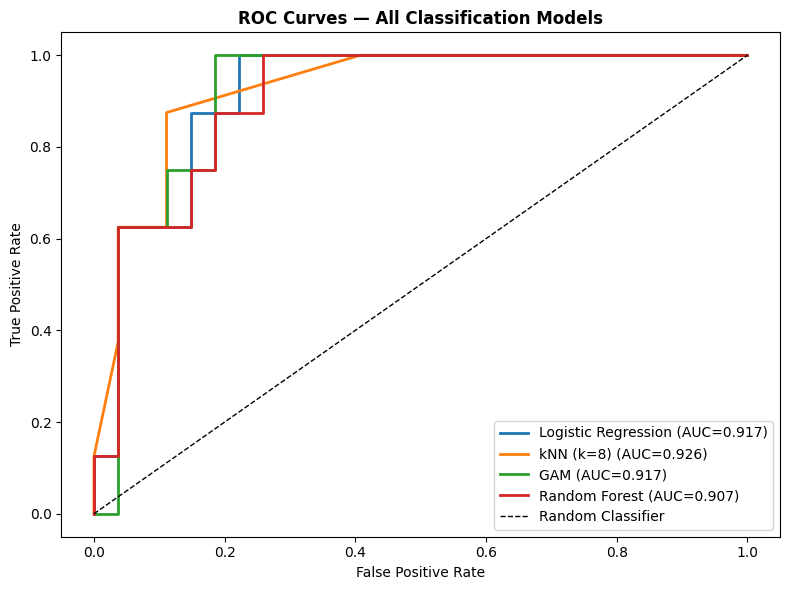

In [259]:
# ============================================================
# ── ROC CURVES — ALL MODELS ──────────────────────────────────
# ============================================================
plt.figure(figsize=(8, 6))
for name, y_prob in [
    ("Logistic Regression", y_prob_log),
    (f"kNN (k={best_k_c})", y_prob_knn_c),
    ("GAM",                 y_prob_gam_c),
    ("Random Forest",       y_prob_rf_c)
]:
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    auc_val      = roc_auc_score(y_test_c, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],"k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Classification Models", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()


  CLASSIFICATION MODEL COMPARISON — FINAL SUMMARY
              Model  Accuracy  AUC-ROC
Logistic Regression  0.885714 0.916667
          kNN (k=8)  0.885714 0.925926
                GAM  0.885714 0.916667
      Random Forest  0.857143 0.907407

✅ Best Model : Logistic Regression
   Accuracy   : 0.8857
   AUC-ROC    : 0.9167


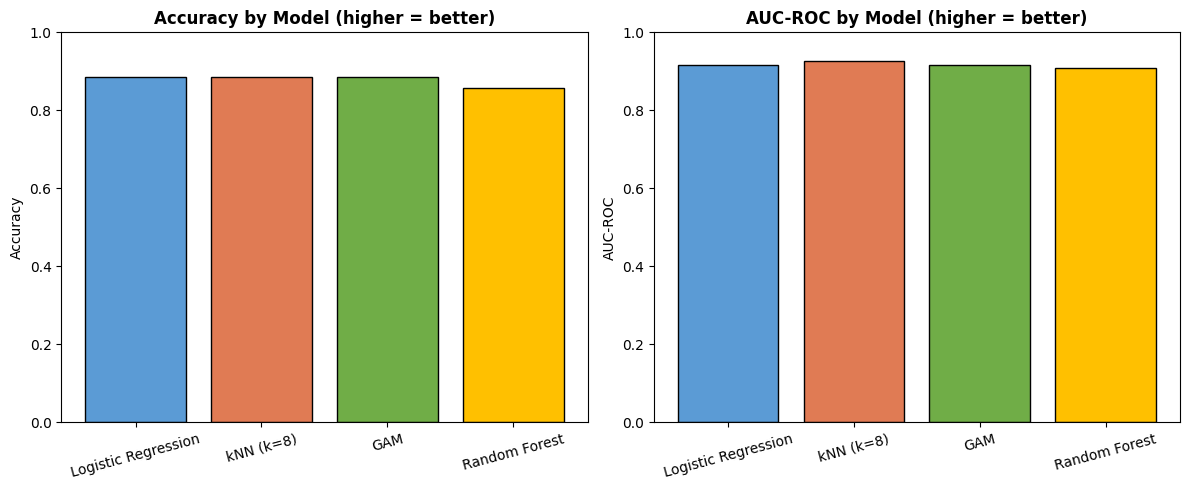

In [264]:
# ============================================================
# ── FINAL CLASSIFICATION COMPARISON ─────────────────────────
# ============================================================
print("\n" + "=" * 55)
print("  CLASSIFICATION MODEL COMPARISON — FINAL SUMMARY")
print("=" * 55)

comparison_c = pd.DataFrame([
    ["Logistic Regression",  acc_log,    auc_log],
    [f"kNN (k={best_k_c})", acc_knn_c,  auc_knn_c],
    ["GAM",                  acc_gam_c,  auc_gam_c],
    ["Random Forest",        acc_rf_c,   auc_rf_c],
], columns=["Model", "Accuracy", "AUC-ROC"])

comparison_c = comparison_c.sort_values(
    "Accuracy", ascending=False).reset_index(drop=True)
print(comparison_c.to_string(index=False))

best_class_name = comparison_c.iloc[0]["Model"]
best_class_acc  = comparison_c.iloc[0]["Accuracy"]
best_class_auc  = comparison_c.iloc[0]["AUC-ROC"]

print(f"\n✅ Best Model : {best_class_name}")
print(f"   Accuracy   : {best_class_acc:.4f}")
print(f"   AUC-ROC    : {best_class_auc:.4f}")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#5b9bd5", "#e07b54", "#70ad47", "#ffc000"]

axes[0].bar(comparison_c["Model"], comparison_c["Accuracy"],
            color=colors, edgecolor="black")
axes[0].set_title("Accuracy by Model (higher = better)", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison_c["Model"], comparison_c["AUC-ROC"],
            color=colors, edgecolor="black")
axes[1].set_title("AUC-ROC by Model (higher = better)", fontweight="bold")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("classification_comparison.png", dpi=150)
plt.show()

In [2]:
#This is Teahun